# 23F-0577
# 23F-0659
# BSCS-7D
# DLP Assignment #1


In [3]:
print("hello")

hello


## Importing Dataset and Libraries

In [4]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
np.random.seed(42) 
train_data = pd.read_csv("fashion-mnist_train.csv")
test_data = pd.read_csv("fashion-mnist_test.csv")

x = train_data.drop("label", axis=1)
y = train_data["label"]
x = x / 255.0        
xtrain, xval, ytrain, yval = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("Number of samples per split")
print("----------------------------")
print("Training samples:", xtrain.shape[0])
print("Validation samples:", xval.shape[0])
print("Test samples:", test_data.shape[0])

print("\nClass distribution (training set)")
print("----------------------------------")
print(ytrain.value_counts().sort_index())

print("\nClass distribution (validation set)")
print("------------------------------------")
print(yval.value_counts().sort_index())

#print(xtrain.shape)
#print(xval.shape)
#print(ytrain.shape)
#print(yval.shape)


xtrain = xtrain[0:5000]
ytrain = ytrain[0:5000]

xtrain = np.array(xtrain).T
ytrain = np.array(ytrain)




Number of samples per split
----------------------------
Training samples: 48000
Validation samples: 12000
Test samples: 10000

Class distribution (training set)
----------------------------------
label
0    4768
1    4826
2    4800
3    4758
4    4815
5    4859
6    4757
7    4776
8    4851
9    4790
Name: count, dtype: int64

Class distribution (validation set)
------------------------------------
label
0    1232
1    1174
2    1200
3    1242
4    1185
5    1141
6    1243
7    1224
8    1149
9    1210
Name: count, dtype: int64


In [5]:
def initParams():
    w1=np.random.randn(64,784)*0.01
    b1=np.zeros((64,1))
    w2=np.random.randn(10,64)*0.01
    b2=np.zeros((10,1))
    return w1, b1, w2, b2

def Relu(z):
    return np.maximum(0, z)

def softmax(z):
    z=z-np.max(z,axis=0,keepdims=True)
    exp_z=np.exp(z)
    return exp_z/np.sum(exp_z,axis=0,keepdims=True)

def forwardPorp(w1,b1,w2,b2,x):
    z1=w1.dot(x)+b1
    a1=Relu(z1)

    z2=w2.dot(a1)+b2
    a2=softmax(z2)

    return z1,a1,z2,a2


def onehot(y):
    one_hot_y=np.zeros((10,y.size))
    one_hot_y[y,np.arange(y.size)]=1
    return one_hot_y

def derRelu(z):
    return z>0

def crossEntropyLoss(a2,y):
    m=y.size
    one_hot_y=onehot(y)
    loss = -np.sum(one_hot_y * np.log(a2 + 1e-8)) / m
    return loss

def backprop(z1,a1,z2,a2,x,y,w2):
    m=y.size
    one_hot_y = onehot(y)

    dz2=a2-one_hot_y
    dw2=(1/m)*dz2.dot(a1.T)
    db2=(1/m)*np.sum(dz2,axis=1,keepdims=True)

    dz1=w2.T.dot(dz2)*derRelu(z1)
    dw1=(1/m)*dz1.dot(x.T)
    db1=(1/m)*np.sum(dz1,axis=1,keepdims=True)

    return dw1,db1,dw2,db2

def updateParams(w1,w2,b1,b2,dw1,dw2,db1,db2,alpha):
    w1=w1-alpha*dw1
    w2=w2-alpha*dw2
    b1=b1-alpha*db1
    b2=b2-alpha*db2

    return w1,b1,w2,b2


In [6]:
def gradientDescent(x, y, epochs, alpha):
    w1,b1,w2,b2=initParams()
    losses=[]
    for i in range(epochs):
        z1,a1,z2,a2=forwardPorp(w1,b1,w2,b2,x)

        loss=crossEntropyLoss(a2,y)
        losses.append(loss)

        dw1,db1,dw2,db2=backprop(z1,a1,z2,a2,x,y,w2)

        w1, b1, w2, b2 = updateParams(w1,w2,b1,b2,dw1,dw2,db1,db2,alpha)
        print("Epoch:",i+1,"Loss:",loss)

    return w1,b1,w2,b2,losses




In [7]:
w1,b1,w2,b2,losses=gradientDescent(xtrain,ytrain,20,0.01)


Epoch: 1 Loss: 2.3026386503810365
Epoch: 2 Loss: 2.3024870541450997
Epoch: 3 Loss: 2.302335485161392
Epoch: 4 Loss: 2.3021839827144097
Epoch: 5 Loss: 2.3020323182903644
Epoch: 6 Loss: 2.30188055601877
Epoch: 7 Loss: 2.3017284616421967
Epoch: 8 Loss: 2.3015758981352374
Epoch: 9 Loss: 2.3014229741121097
Epoch: 10 Loss: 2.3012696916944058
Epoch: 11 Loss: 2.3011159491461846
Epoch: 12 Loss: 2.3009615579849094
Epoch: 13 Loss: 2.300806585685799
Epoch: 14 Loss: 2.300650848507344
Epoch: 15 Loss: 2.300494255125472
Epoch: 16 Loss: 2.3003368515121574
Epoch: 17 Loss: 2.3001786594148212
Epoch: 18 Loss: 2.3000196118636533
Epoch: 19 Loss: 2.299859693709014
Epoch: 20 Loss: 2.2996987215358566


C:\Users\Sabri laptop\AppData\Local\Temp\ipykernel_2088\1172550612.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


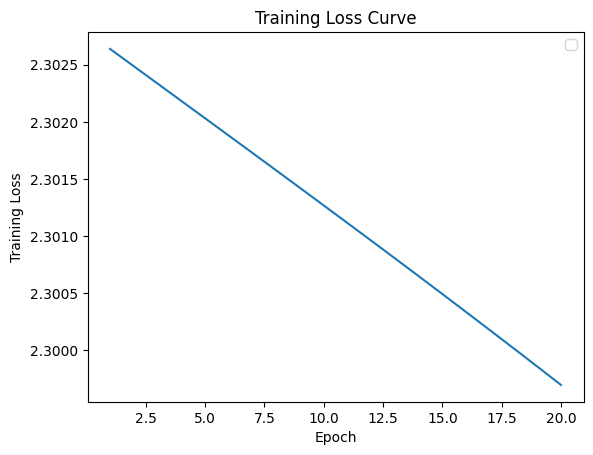

In [8]:
plt.plot(range(1, 21), losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.legend() 
plt.show()

## Same Process with Pytorch

In [9]:
import torch
import torch.nn as nn

batchSize=64
xbatch=xtrain[:, :batchSize]
ybatch=ytrain[:batchSize]


np.random.seed(42)
w1test=np.random.randn(64,784)*0.01
b1test=np.zeros((64,1))

w2test=np.random.randn(10,64)*0.01
b2test=np.zeros((10,1))


z1,a1,z2,a2=forwardPorp(w1test,b1test,w2test,b2test,xbatch)
dw1np,db1np,dw2np,db2np = backprop(z1,a1,z2,a2,xbatch,ybatch,w2test)

class TwoLayerMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(784, 64)
        self.layer2 = nn.Linear(64, 10)


    def forward(self, x):
        x = self.layer1(x)
        x = torch.relu(x)
        x = self.layer2(x)
        return x

model=TwoLayerMLP()

with torch.no_grad():
    model.layer1.weight.copy_(torch.tensor(w1test, dtype=torch.float32))
    model.layer1.bias.copy_(torch.tensor(b1test.reshape(64), dtype=torch.float32))
    model.layer2.weight.copy_(torch.tensor(w2test, dtype=torch.float32))
    model.layer2.bias.copy_(torch.tensor(b2test.reshape(10), dtype=torch.float32))
x_torch=torch.tensor(xbatch.T,dtype=torch.float32)
y_torch=torch.tensor(ybatch,dtype=torch.long)

output=model(x_torch)
criterion=nn.CrossEntropyLoss()
lossTorch=criterion(output,y_torch)
lossTorch.backward()

dw1torch=model.layer1.weight.grad.detach().numpy()
dw2torch=model.layer2.weight.grad.detach().numpy()
difference_w1=np.max(np.abs(dw1np - dw1torch))
difference_w2=np.max(np.abs(dw2np - dw2torch))


print()
print("Gradient Verification")
print("---------------------")
print("Maximum absolute difference for W1:",difference_w1)
print("Maximum absolute difference for W2:",difference_w2)


Gradient Verification
---------------------
Maximum absolute difference for W1: 5.309646151571701e-10
Maximum absolute difference for W2: 4.7635711156873706e-09


## 3.Baseline Model and Activation Study

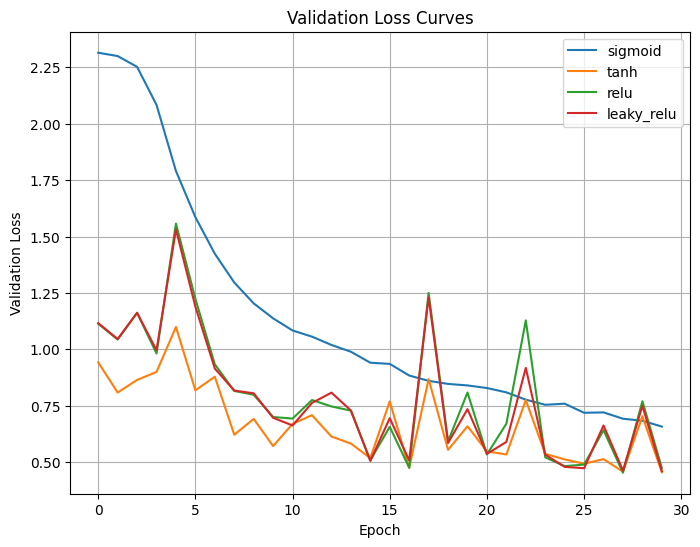

Mean Absolute Gradient of First Hidden Layer
---------------------------------------------
Sigmoid - Epoch 1: 0.00010535295587033033
Sigmoid - Final Epoch: 0.0002678681630641222
ReLU - Epoch 1: 0.0017630541697144508
ReLU - Final Epoch: 0.0018084915354847908
ReLU Dead Unit Percentage:
6.25 %


In [10]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

xtraintorch=torch.tensor(xtrain.T, dtype=torch.float32)
ytraintorch=torch.tensor(ytrain, dtype=torch.long)

xvaltorch=torch.tensor(np.array(xval), dtype=torch.float32)
yvaltorch=torch.tensor(np.array(yval), dtype=torch.long)

class MLP(nn.Module):
    def __init__(self, activation):
        super().__init__()

        self.layer1=nn.Linear(784, 128)
        self.layer2=nn.Linear(128, 64)
        self.layer3=nn.Linear(64, 10)

        if activation=="sigmoid":
            self.act=nn.Sigmoid()
        elif activation=="tanh":
            self.act=nn.Tanh()
        elif activation=="relu":
            self.act=nn.ReLU()
        else:
            self.act=nn.LeakyReLU(0.01)

    def forward(self, x):
        x=self.layer1(x)
        x=self.act(x)
        x=self.layer2(x)
        x=self.act(x)
        x=self.layer3(x)

        return x


# Train model
def train_model(activation):

    torch.manual_seed(42)

    model=MLP(activation)
    criterion=nn.CrossEntropyLoss()
    losses=[]

    gradepoch1=0
    gradfinal=0

    for epoch in range(30):

        permutation=torch.randperm(len(xtraintorch))
        
        for start in range(0,len(ytraintorch),64):
            
            index=permutation[start:start+64]
            
            xb=xtraintorch[index]
            yb=ytraintorch[index]
            output=model(xb)
            loss=criterion(output,yb)
            loss.backward()

            with torch.no_grad():
                for parameter in model.parameters():
                    parameter -=0.1*parameter.grad
            model.zero_grad()

        with torch.no_grad():
            output=model(xvaltorch)
            validationloss=criterion(output, yvaltorch)

        losses.append(validationloss.item())

        model.zero_grad()

        output = model(xvaltorch[:256])
        loss = criterion(output, yvaltorch[:256])
        loss.backward()
        gradient = model.layer1.weight.grad.abs().mean().item()

        if epoch == 0:
            gradepoch1 = gradient
        if epoch == 29:
            gradfinal = gradient
    return model, losses, gradepoch1, gradfinal

activations = ["sigmoid", "tanh", "relu", "leaky_relu"]
results = {}
for activation in activations:
    model, losses, grad1, gradfinal = train_model(activation)
    results[activation]={"model": model,"losses": losses,"gradepoch1": grad1,"gradfinal": gradfinal}

plt.figure(figsize=(8, 6))

for activation in activations:
    plt.plot(results[activation]["losses"],label=activation)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.show()


print("Mean Absolute Gradient of First Hidden Layer")
print("---------------------------------------------")
print("Sigmoid - Epoch 1:",results["sigmoid"]["gradepoch1"])
print("Sigmoid - Final Epoch:",results["sigmoid"]["gradfinal"])
print("ReLU - Epoch 1:",results["relu"]["gradepoch1"])
print("ReLU - Final Epoch:",results["relu"]["gradfinal"])


# ReLU dead units
relu_model = results["relu"]["model"]
relu_model.eval()
with torch.no_grad():

    hidden = relu_model.layer1(xvaltorch[:256])
    hidden = relu_model.act(hidden)

    dead_units = (hidden == 0).all(dim=0)

    dead_percentage = dead_units.float().mean().item() * 100

print("ReLU Dead Unit Percentage:")
print(round(dead_percentage, 2), "%")

In [11]:
baseline_model = results["relu"]["model"]
baseline_model.eval()

with torch.no_grad():
    output = baseline_model(xvaltorch)
    predictions = torch.argmax(output, dim=1)
baseline_accuracy = (predictions == yvaltorch).float().mean().item() * 100

print("Baseline Accuracy:", round(baseline_accuracy, 2), "%")

Baseline Accuracy: 83.59 %


## Part 3: Loss Functions

Validation Accuracy
--------------------
Cross-Entropy model: 83.49 %
MSE model: 67.49 %


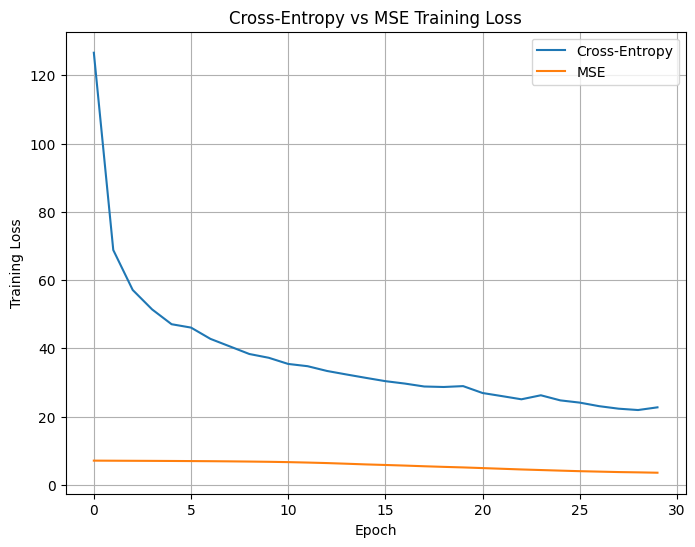

In [50]:

def trainWithLoss(loss_type):

    torch.manual_seed(42)
    model = MLP("relu")

    if loss_type == "cross_entropy":
        criterion = nn.CrossEntropyLoss()
    else:
        criterion = nn.MSELoss()
    losses = []
    ytrain_onehot = torch.zeros(len(ytraintorch), 10)
    ytrain_onehot.scatter_(1,ytraintorch.unsqueeze(1),1)

    for epoch in range(30):

        permutation = torch.randperm(len(xtraintorch))
        epoch_loss = 0

        for start in range(0, len(ytraintorch), 64):
            index = permutation[start:start + 64]
            xb = xtraintorch[index]
            output = model(xb)

            if loss_type == "cross_entropy":
                yb = ytraintorch[index]
                loss = criterion(output, yb)
            else:
                ybonehot = ytrain_onehot[index]
                probabilities = torch.softmax(output, dim=1)
                loss = criterion(probabilities, ybonehot)

            loss.backward()

            with torch.no_grad():
                for parameter in model.parameters():
                    parameter -= 0.1 * parameter.grad

            epoch_loss += loss.item()
            model.zero_grad()
        losses.append(epoch_loss)
    model.eval()
    with torch.no_grad():
        output = model(xvaltorch)
        predictions = torch.argmax(output, dim=1)
        accuracy = (predictions == yvaltorch).float().mean().item() * 100
    return model, losses, accuracy

CrossModel, CrossLoss,CrossAccuracy = trainWithLoss("cross_entropy")
MSEMOdel, MSELoss,MSEAccuracy = trainWithLoss("mse")

print("Validation Accuracy")
print("--------------------")
print("Cross-Entropy model:", round(CrossAccuracy, 2), "%")
print("MSE model:", round(MSEAccuracy, 2), "%")

plt.figure(figsize=(8, 6))
plt.plot(CrossLoss,label="Cross-Entropy")
plt.plot(MSELoss,label="MSE")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Cross-Entropy vs MSE Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [51]:
# TABULAR REGRESSION - PAKISTAN CRICKET DATA

import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

data = pd.read_csv("pakistan_cricket_regression.csv")

X = data[["Balls_Faced", "Strike_Rate", "Batting_Average"]]
y = data["Runs_Scored"]

xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

scaler=StandardScaler()
xtrain=scaler.fit_transform(xtrain)
xtest=scaler.transform(xtest)

xtraint=torch.tensor(xtrain, dtype=torch.float32)
ytraint=torch.tensor(ytrain.values, dtype=torch.float32).reshape(-1, 1)

xtestt=torch.tensor(xtest, dtype=torch.float32)
ytestt=torch.tensor(ytest.values, dtype=torch.float32).reshape(-1, 1)

class RegressionMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(3, 16)
        self.layer2 = nn.Linear(16, 8)
        self.layer3 = nn.Linear(8, 1)

        self.act = nn.ReLU()
    def forward(self, x):

        x = self.layer1(x)
        x = self.act(x)

        x = self.layer2(x)
        x = self.act(x)

        x = self.layer3(x)

        return x


# Create model
model = RegressionMLP()
criterion = nn.MSELoss()

for epoch in range(500):

    output = model(xtraint)
    loss = criterion(output, ytraint)
    loss.backward()

    with torch.no_grad():
        for parameter in model.parameters():
            parameter -= 0.01 * parameter.grad

    model.zero_grad()


with torch.no_grad():
    predictions = model(xtestt)

predictions = predictions.numpy()
actual = ytestt.numpy()

mse = mean_squared_error(actual, predictions)
rmse = math.sqrt(mse)
mae = mean_absolute_error(actual, predictions)

print("Regression Test Results")
print("-----------------------")
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("MAE:", round(mae, 2))

Regression Test Results
-----------------------
MSE: 2111.15
RMSE: 45.95
MAE: 37.2


## Part 4: Optimiser Comparison


Optimizer Comparison (Same Learning Rate = 0.01 for all)
----------------------------------------------------------
Optimizer            Epochs to 85%        Final Accuracy       Wall-clock Time
SGD                  Not reached          78.63                4.04 sec
SGD + momentum       Not reached          83.37                4.15 sec
RMSProp              Not reached          83.97                4.85 sec
Adam                 Not reached          83.59                6.1 sec

Optimizer Comparison
--------------------
Optimizer            Learning Rate   Epochs to 85%        Final Accuracy       Wall-clock Time
SGD                  0.01            Not reached          78.63                3.97 sec
SGD + momentum       0.01            Not reached          83.37                4.41 sec
RMSProp              0.001           30                   85.01                5.27 sec
Adam                 0.001           Not reached          83.61                6.27 sec


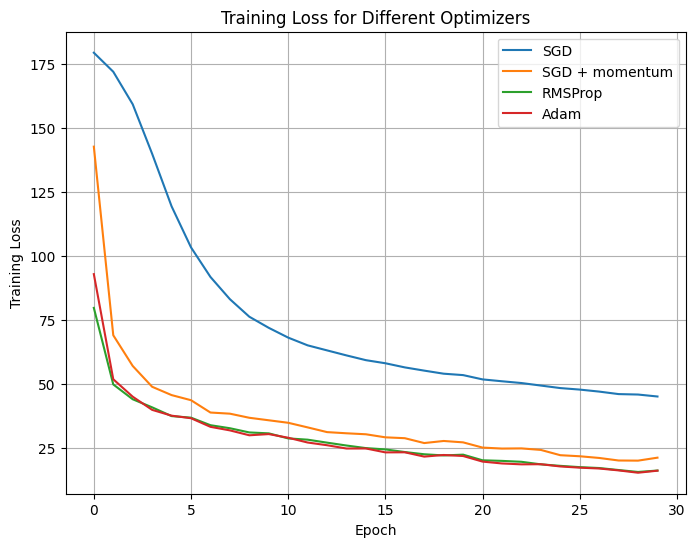

In [52]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time


def trainOptimzer(OptName, lrr, epo=30):

    torch.manual_seed(42)
    model = MLP("relu")

    criterion = nn.CrossEntropyLoss()
    if OptName == "SGD":
        optimizer = torch.optim.SGD( model.parameters(),lr=lrr)

    elif OptName == "SGD + momentum":
        optimizer = torch.optim.SGD(model.parameters(),lr=lrr,momentum=0.9)

    elif OptName == "RMSProp":
        optimizer = torch.optim.RMSprop(model.parameters(),lr=lrr)

    elif OptName == "Adam":
        optimizer = torch.optim.Adam(model.parameters(),lr=lrr)

    losses = []
    tempepoch = None

    start_time = time.time()
    for epoch in range(epo):

        permutation = torch.randperm(len(xtraintorch))
        epochloss = 0

        for start in range(0, len(ytraintorch), 64):

            index = permutation[start:start + 64]

            xb = xtraintorch[index]
            yb = ytraintorch[index]

            output = model(xb)
            loss = criterion(output, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epochloss += loss.item()
        losses.append(epochloss)

        with torch.no_grad():
            output = model(xvaltorch)
            predictions = torch.argmax(output, dim=1)
            accuracy = ((predictions == yvaltorch).float().mean().item()* 100)
        if tempepoch is None and accuracy >= 85:
            tempepoch = epoch + 1

    wall_time = time.time() - start_time
    return model, losses, tempepoch, accuracy, wall_time

optimizers = ["SGD","SGD + momentum","RMSProp","Adam"]
samelr = 0.01

sameLRResults = {}
for optimizerName in optimizers:
    model, losses, tempepoch85, accuracy, wall_time = trainOptimzer(optimizerName,samelr)
    sameLRResults[optimizerName] = {"losses": losses,"epoch85": tempepoch85,"accuracy": accuracy,"time": wall_time}
    
print("\nOptimizer Comparison (Same Learning Rate = 0.01 for all)")
print("----------------------------------------------------------")
print("Optimizer".ljust(20),"Epochs to 85%".ljust(20),"Final Accuracy".ljust(20),"Wall-clock Time")

for optimizerName in optimizers:
    result = sameLRResults[optimizerName]
    tempepoch85 = result["epoch85"]
    if tempepoch85 is None:
        tempepoch85 = "Not reached"

    print(optimizerName.ljust(20),str(tempepoch85).ljust(20),str(round(result["accuracy"], 2)).ljust(20),str(round(result["time"], 2)) + " sec")
# END FIX


tunedlr = {"SGD": 0.01,"SGD + momentum": 0.01,"RMSProp": 0.001,"Adam": 0.001}

results = {}
for optimizerName in optimizers:
    model, losses, tempepoch85, accuracy, wall_time = trainOptimzer(optimizerName,tunedlr[optimizerName])
    results[optimizerName] = {"learning_rate": tunedlr[optimizerName],"losses": losses,"epoch85": tempepoch85,"accuracy": accuracy,"time": wall_time}

print("\nOptimizer Comparison")
print("--------------------")

print("Optimizer".ljust(20),"Learning Rate".ljust(15),"Epochs to 85%".ljust(20),"Final Accuracy".ljust(20),"Wall-clock Time")

for optimizerName in optimizers:

    result = results[optimizerName]

    tempepoch85 = result["epoch85"]

    if tempepoch85 is None:
        tempepoch85 = "Not reached"

    print(
        optimizerName.ljust(20),
        str(result["learning_rate"]).ljust(15),
        str(tempepoch85).ljust(20),
        str(round(result["accuracy"], 2)).ljust(20),
        str(round(result["time"], 2)) + " sec"
    )

plt.figure(figsize=(8, 6))
for optimizerName in optimizers:

    plt.plot(results[optimizerName]["losses"], label=optimizerName)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss for Different Optimizers")
plt.legend()
plt.grid(True)
plt.show()

## Part 5: Forcing Overfitting

Epoch: 1 Training Accuracy: 22.05 Validation Accuracy: 20.63
Epoch: 2 Training Accuracy: 33.9 Validation Accuracy: 32.22
Epoch: 3 Training Accuracy: 20.95 Validation Accuracy: 20.8
Epoch: 4 Training Accuracy: 40.95 Validation Accuracy: 39.88
Epoch: 5 Training Accuracy: 47.35 Validation Accuracy: 46.31
Epoch: 6 Training Accuracy: 46.3 Validation Accuracy: 46.5
Epoch: 7 Training Accuracy: 64.0 Validation Accuracy: 63.73
Epoch: 8 Training Accuracy: 51.15 Validation Accuracy: 52.27
Epoch: 9 Training Accuracy: 59.8 Validation Accuracy: 59.4
Epoch: 10 Training Accuracy: 60.1 Validation Accuracy: 59.04
Epoch: 11 Training Accuracy: 70.85 Validation Accuracy: 69.41
Epoch: 12 Training Accuracy: 68.35 Validation Accuracy: 67.18
Epoch: 13 Training Accuracy: 70.8 Validation Accuracy: 69.31
Epoch: 14 Training Accuracy: 76.7 Validation Accuracy: 73.78
Epoch: 15 Training Accuracy: 74.35 Validation Accuracy: 71.91
Epoch: 16 Training Accuracy: 68.55 Validation Accuracy: 67.13
Epoch: 17 Training Accuracy

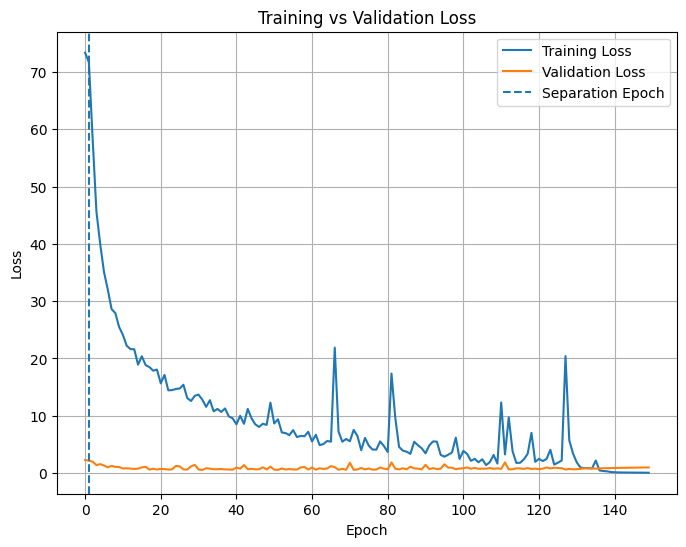

In [53]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

smalltrainx = xtraintorch[:2000]
smalltrainy = ytraintorch[:2000]

class LargeMLP(nn.Module):

    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(784, 512)
        self.layer2 = nn.Linear(512, 512)
        self.layer3 = nn.Linear(512, 512)
        self.layer4 = nn.Linear(512, 512)
        self.layer5 = nn.Linear(512, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.relu(self.layer4(x))
        x = self.layer5(x)
        return x


torch.manual_seed(42)
model = LargeMLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(),lr=0.1)

# Training
epochs = 150

trainLosses = []
validationLosses = []

trainAccuracies = []
validationAccuracies = []


for epoch in range(epochs):
    permutation = torch.randperm(len(smalltrainx))
    epoch_loss = 0
    for start in range(0, len(smalltrainx), 64):
        index = permutation[start:start + 64]
        xb = smalltrainx[index]
        yb = smalltrainy[index]
        output = model(xb)
        loss = criterion(output, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    trainLosses.append(epoch_loss)


    # Training accuracy

    with torch.no_grad():
        output = model(smalltrainx)
        predictions = torch.argmax(output, dim=1)
        trainAccuracy = ((predictions == smalltrainy).float().mean().item()* 100)

    # Validation loss and accuracy
    with torch.no_grad():
        output = model(xvaltorch)

        validationLoss = criterion(output,yvaltorch)
        predictions = torch.argmax(output, dim=1)
        validationAccuracy = ((predictions == yvaltorch).float().mean().item()* 100)

    validationLosses.append(validationLoss.item())

    trainAccuracies.append(trainAccuracy)
    validationAccuracies.append(validationAccuracy)

    print("Epoch:", epoch + 1,"Training Accuracy:", round(trainAccuracy, 2), "Validation Accuracy:", round(validationAccuracy, 2))

# Find epoch where training and validation loss separate
separationEpoch = 0
for i in range(1, len(trainLosses)):
    if trainLosses[i] > validationLosses[i]:
        separationEpoch = i + 1
        break


# Final generalisation gap
generalisationGap = (trainAccuracies[-1]- validationAccuracies[-1])

print("\nGeneralisation Results")
print("----------------------")
print("Final Training Accuracy:", round(trainAccuracies[-1], 2),"%")
print("Final Validation Accuracy:",round(validationAccuracies[-1], 2),"%")
print("Generalisation Gap:",round(generalisationGap, 2),"%")
print("Separation Epoch:",separationEpoch)

# Plot training and validation loss

plt.figure(figsize=(8, 6))
plt.plot(trainLosses,label="Training Loss")
plt.plot(validationLosses,label="Validation Loss")
plt.axvline(separationEpoch - 1,linestyle="--",label="Separation Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## Part 6: Regularisation Study

In [55]:
print(len(x))
print(len(y))

60000
200



Method                         Setting                         Train     Validation     Gap
----------------------------------------------------------------------------------------------------
Baseline (no regularisation)   -                              100.00    82.82          17.18
L2 weight decay                λ=0.0001                       85.10     74.27          10.83
L2 weight decay                λ=0.001                        76.25     69.40          6.85
L2 weight decay                λ=0.01                         82.30     75.52          6.78
L1 penalty                     λ=0.0001, weights <1e-3=86.56% 93.95     80.82          13.13
Dropout                        p=0.2                          97.15     80.98          16.17
Dropout                        p=0.5                          88.00     77.57          10.43
Dropout                        p=0.8                          42.05     39.91          2.14
Batch normalisation            BatchNorm1d                    68.

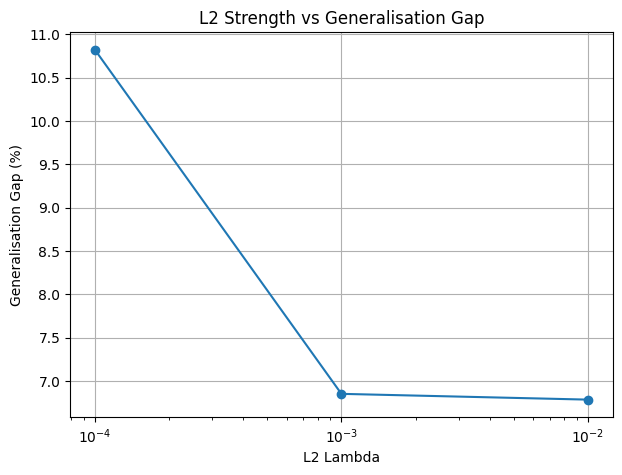

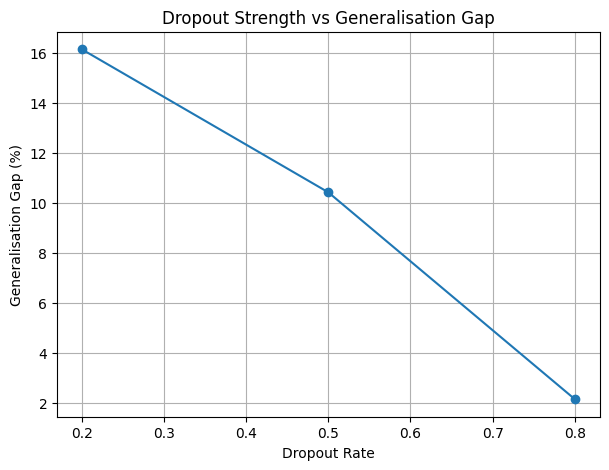

In [56]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision.transforms.functional import rotate


# MODEL
class LargeMLP(nn.Module):
    def __init__(self, dropout=0, batchnorm=False):
        super().__init__()
        self.layer1 = nn.Linear(784, 512)
        self.layer2 = nn.Linear(512, 512)
        self.layer3 = nn.Linear(512, 512)
        self.layer4 = nn.Linear(512, 512)
        self.layer5 = nn.Linear(512, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.batchnorm = batchnorm
        if batchnorm:
            self.bn1 = nn.BatchNorm1d(512)
            self.bn2 = nn.BatchNorm1d(512)
            self.bn3 = nn.BatchNorm1d(512)
            self.bn4 = nn.BatchNorm1d(512)

    def forward(self, x):
        x = self.layer1(x)
        if self.batchnorm: x = self.bn1(x)
        x = self.dropout(self.relu(x))
        x = self.layer2(x)
        if self.batchnorm: x = self.bn2(x)
        x = self.dropout(self.relu(x))
        x = self.layer3(x)
        if self.batchnorm: x = self.bn3(x)
        x = self.dropout(self.relu(x))
        x = self.layer4(x)
        if self.batchnorm: x = self.bn4(x)
        x = self.dropout(self.relu(x))
        return self.layer5(x)


# TRAINING FUNCTION
def trainmodel(X, y, weightdecay=0, l1=0, dropout=0, batchnorm=False, earlystop=False, patience=10, augmentation=False):
    torch.manual_seed(42)
    model = LargeMLP(dropout, batchnorm)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, weight_decay=weightdecay)
    bestval = 0
    beststate = None
    noimprove = 0
    stopepoch = 150

    for epoch in range(150):
        model.train()
        order = torch.randperm(len(X))
        for start in range(0, len(X), 64):
            index = order[start:start + 64]
            xb = X[index]
            yb = y[index]

            # Data augmentation
            if augmentation:
                xb = xb.view(-1, 1, 28, 28)
                for i in range(len(xb)):
                    if torch.rand(1).item() < 0.5:
                        xb[i] = torch.flip(xb[i], [2])
                    angle = torch.rand(1).item() * 10 - 5
                    xb[i] = rotate(xb[i], angle)
                xb = xb.view(-1, 784)

            output = model(xb)
            loss = criterion(output, yb)

            # L1 penalty
            if l1 > 0:
                l1loss = 0
                for p in model.parameters():
                    l1loss += torch.sum(torch.abs(p))
                loss = loss + l1 * l1loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Accuracy
        model.eval()
        with torch.no_grad():
            trainout = model(X)
            trainpred = torch.argmax(trainout, dim=1)
            trainacc = (trainpred == y).float().mean().item() * 100

            valout = model(xvaltorch)
            valpred = torch.argmax(valout, dim=1)
            valacc = (valpred == yvaltorch).float().mean().item() * 100

        # Early stopping
        if earlystop:
            if valacc > bestval:
                bestval = valacc
                beststate = {k: v.clone() for k, v in model.state_dict().items()}
                noimprove = 0
            else:
                noimprove += 1
            if noimprove >= patience:
                stopepoch = epoch + 1
                break

    # Restore best model
    if earlystop and beststate is not None:
        model.load_state_dict(beststate)
        with torch.no_grad():
            trainpred = torch.argmax(model(X), dim=1)
            valpred = torch.argmax(model(xvaltorch), dim=1)
            trainacc = (trainpred == y).float().mean().item() * 100
            valacc = (valpred == yvaltorch).float().mean().item() * 100

    gap = trainacc - valacc
    return model, trainacc, valacc, gap, stopepoch


# RESULTS
results = []

# Baseline
model, trainacc, valacc, gap, stopepoch = trainmodel(xtraintorch[:2000], ytraintorch[:2000])
results.append(["Baseline (no regularisation)", "-", trainacc, valacc, gap])

# L2
for value in [0.0001, 0.001, 0.01]:
    model, trainacc, valacc, gap, stopepoch = trainmodel(xtraintorch[:2000], ytraintorch[:2000], weightdecay=value)
    results.append(["L2 weight decay", "λ=" + str(value), trainacc, valacc, gap])

# L1
l1value = 0.0001
model, trainacc, valacc, gap, stopepoch = trainmodel(xtraintorch[:2000], ytraintorch[:2000], l1=l1value)
total = 0
small = 0
for p in model.parameters():
    if len(p.shape) > 1:
        total += p.numel()
        small += (torch.abs(p) < 1e-3).sum().item()
smallpercent = small / total * 100
results.append(["L1 penalty", "λ=" + str(l1value) + ", weights <1e-3=" + str(round(smallpercent, 2)) + "%", trainacc, valacc, gap])

# Dropout
for value in [0.2, 0.5, 0.8]:
    model, trainacc, valacc, gap, stopepoch = trainmodel(xtraintorch[:2000], ytraintorch[:2000], dropout=value)
    results.append(["Dropout", "p=" + str(value), trainacc, valacc, gap])

# Batch Normalisation
model, trainacc, valacc, gap, stopepoch = trainmodel(xtraintorch[:2000], ytraintorch[:2000], batchnorm=True)
results.append(["Batch normalisation", "BatchNorm1d", trainacc, valacc, gap])

# Early Stopping
model, trainacc, valacc, gap, stopepoch = trainmodel(xtraintorch[:2000], ytraintorch[:2000], earlystop=True, patience=10)
results.append(["Early stopping", "Patience=10, stopped=" + str(stopepoch), trainacc, valacc, gap])

# Data Augmentation
model, trainacc, valacc, gap, stopepoch = trainmodel(xtraintorch[:2000], ytraintorch[:2000], augmentation=True)
results.append(["Data augmentation", "Random horizontal flip + rotation ±5°", trainacc, valacc, gap])


xFull = train_data.drop("label", axis=1) / 255.0
yFull = train_data["label"]

xtrainFull, _, ytrainFull, _ = train_test_split(xFull, yFull, test_size=0.2, random_state=42)
xtrainFullTorch = torch.tensor(np.array(xtrainFull), dtype=torch.float32)
ytrainFullTorch = torch.tensor(np.array(ytrainFull), dtype=torch.long)
# More training data: 10,000
model, trainacc, valacc, gap, stopepoch = trainmodel(xtrainFullTorch[:10000], ytrainFullTorch[:10000])
results.append(["More training data", "10,000", trainacc, valacc, gap])

# More training data: 20,000
model, trainacc, valacc, gap, stopepoch = trainmodel(xtrainFullTorch[:20000], ytrainFullTorch[:20000])
results.append(["More training data", "20,000", trainacc, valacc, gap])

# FINAL TABLE
print("\nMethod                         Setting                         Train     Validation     Gap")
print("-" * 100)
for r in results:
    print("{:<30} {:<30} {:<9.2f} {:<14.2f} {:.2f}".format(r[0], r[1], r[2], r[3], r[4]))

# L2 PLOT
l2x = [0.0001, 0.001, 0.01]
l2y = []
for r in results:
    if r[0] == "L2 weight decay":
        l2y.append(r[4])

plt.figure(figsize=(7, 5))
plt.plot(l2x, l2y, marker="o")
plt.xscale("log")
plt.xlabel("L2 Lambda")
plt.ylabel("Generalisation Gap (%)")
plt.title("L2 Strength vs Generalisation Gap")
plt.grid(True)
plt.show()

# DROPOUT PLOT
dropoutx = [0.2, 0.5, 0.8]
dropouty = []
for r in results:
    if r[0] == "Dropout":
        dropouty.append(r[4])

plt.figure(figsize=(7, 5))
plt.plot(dropoutx, dropouty, marker="o")
plt.xlabel("Dropout Rate")
plt.ylabel("Generalisation Gap (%)")
plt.title("Dropout Strength vs Generalisation Gap")
plt.grid(True)
plt.show()

## Part 7: Hyperparameter Tuning with k-Fold Cross-Validation

In [58]:
import torch
import torch.nn as nn
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

lr = [0.001, 0.003, 0.01, 0.03]
hiddenWidths = [128, 256, 512]
dropoutRates = [0.0, 0.2, 0.5]

print("Hyperparameter Search Space")
print("----------------------------")
print("Learning rate:", lr)
print("Hidden width:", hiddenWidths)
print("Dropout rate:", dropoutRates)

class TunedMLP(nn.Module):
    def __init__(self, hidden_width, dropout_rate, batchnorm=False):
        super().__init__()
        self.layer1 = nn.Linear(784, hidden_width)
        self.layer2 = nn.Linear(hidden_width, hidden_width)
        self.layer3 = nn.Linear(hidden_width, 64)
        self.layer4 = nn.Linear(64, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

        self.batchnorm = batchnorm
        if batchnorm:
            self.bn1 = nn.BatchNorm1d(hidden_width)
            self.bn2 = nn.BatchNorm1d(hidden_width)
            self.bn3 = nn.BatchNorm1d(64)

    def forward(self, x):
        x = self.layer1(x)
        if self.batchnorm: x = self.bn1(x)  
        x = self.relu(x)
        x = self.dropout(x)
        x = self.layer2(x)
        if self.batchnorm: x = self.bn2(x)   
        x = self.relu(x)
        x = self.dropout(x)
        x = self.layer3(x)
        if self.batchnorm: x = self.bn3(x)   
        x = self.relu(x)
        x = self.dropout(x)
        x = self.layer4(x)
        return x

def train_fold(xtrain, ytrain, xvalid, yvalid, lrr, hiddernWidth, dropoutRate):
    torch.manual_seed(42)
    model = TunedMLP(hiddernWidth,dropoutRate)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(),lr=lrr)
    for epoch in range(20):
        permutation = torch.randperm(len(xtrain))
        for start in range(0, len(xtrain), 64):
            index = permutation[start:start + 64]
            xb = xtrain[index]
            yb = ytrain[index]
            output = model(xb)
            loss = criterion(output, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    model.eval()
    with torch.no_grad():
        output = model(xvalid)
        predictions = torch.argmax(output,dim=1)
        accuracy = ((predictions == yvalid).float().mean().item())
    return accuracy

random.seed(42)
configurations = []
for i in range(12):
    learning_rate = random.choice(lr)
    hidden_width = random.choice(hiddenWidths)
    dropout_rate = random.choice(dropoutRates)
    configurations.append((learning_rate,hidden_width,dropout_rate))

#5-FOLD CROSS-VALIDATION
kf = KFold(n_splits=5,shuffle=True,random_state=42)
search_results = []
for configuration in configurations:
    clr = configuration[0]
    hiddenWidth = configuration[1]
    dropoutRate = configuration[2]
    foldScores = []
    for train_index, valid_index in kf.split(xtraintorch):
        Xtrain = xtraintorch[train_index]
        ytrainFold = ytraintorch[train_index]  
        Xvalid = xtraintorch[valid_index]
        yvalidFold = ytraintorch[valid_index]
        accuracy = train_fold(Xtrain,ytrainFold,Xvalid,yvalidFold,clr,hiddenWidth,dropoutRate)
        foldScores.append(accuracy)

    meanScore = np.mean(foldScores)
    stdScore = np.std(foldScores)
    search_results.append({"learning_rate": clr,"hidden_width": hiddenWidth,"dropout_rate": dropoutRate,"mean_score": meanScore,"std_score": stdScore})
search_results.sort(key=lambda result: result["mean_score"],reverse=True)
print("\nTop Five Configurations")
print("-----------------------")
for i in range(5):
    result = search_results[i]
    print("\nConfiguration", i + 1)
    print("Learning Rate:",result["learning_rate"])
    print("Hidden Width:",result["hidden_width"])
    print("Dropout Rate:",result["dropout_rate"])
    print("Mean CV Accuracy:",round(result["mean_score"] * 100, 2),"%")
    print("Standard Deviation:",round(result["std_score"] * 100, 2),"%")
best = search_results[0]
best_learning_rate = best["learning_rate"]
best_hidden_width = best["hidden_width"]
best_dropout_rate = best["dropout_rate"]
print("\nSelected Configuration")
print("----------------------")
print("Learning Rate:",best_learning_rate)
print("Hidden Width:",best_hidden_width)
print("Dropout Rate:",best_dropout_rate)

best_reg_method = None
best_reg_setting = None
smallest_gap = None

for row in results:
    method_name = row[0]
    setting = row[1]
    gap = row[4]

    if method_name == "Baseline (no regularisation)":
        continue   

    if smallest_gap is None or gap < smallest_gap:
        smallest_gap = gap
        best_reg_method = method_name
        best_reg_setting = setting

print("\nBest Regularisation Carried Over From Part 6")
print("----------------------------------------------")
print("Method:", best_reg_method)
print("Setting:", best_reg_setting)
print("Gap:", smallest_gap)

use_batchnorm = False
weight_decay = 0.0

if best_reg_method == "Batch normalisation":
    use_batchnorm = True

if best_reg_method == "L2 weight decay":
    parts = best_reg_setting.split("=")
    weight_decay = float(parts[1])

torch.manual_seed(42)
finalModel = TunedMLP(best_hidden_width, best_dropout_rate, batchnorm=use_batchnorm) 
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(finalModel.parameters(), lr=best_learning_rate, weight_decay=weight_decay) 

for epoch in range(30):
    permutation = torch.randperm(len(xtraintorch))
    for start in range(0, len(xtraintorch), 64):
        index = permutation[start:start + 64]
        xb = xtraintorch[index]
        yb = ytraintorch[index]
        output = finalModel(xb)
        loss = criterion(output, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
finalModel.eval()

#test data 
xtest_raw = test_data.drop("label", axis=1) / 255.0
ytest_raw = test_data["label"]
xtesttorch = torch.tensor(np.array(xtest_raw), dtype=torch.float32)
ytesttorch = torch.tensor(np.array(ytest_raw), dtype=torch.long)

with torch.no_grad():
    output = finalModel(xtesttorch)
    predictions = torch.argmax(output,dim=1)

# Accuracy
testAccuracy = ((predictions == ytesttorch).float().mean().item())
# Macro Precision
macroPrecision = precision_score(ytesttorch.numpy(),predictions.numpy(),average="macro")
# Macro Recall
macroRecall = recall_score(ytesttorch.numpy(),predictions.numpy(),average="macro")
# Macro F1
macroF1 = f1_score(ytesttorch.numpy(),predictions.numpy(),average="macro")
# Confusion Matrix
cm = confusion_matrix(ytesttorch.numpy(),predictions.numpy())
# END FIX

print("\nFinal Test Results")
print("------------------")
print("Accuracy:",round(testAccuracy * 100, 2),"%")
print("Macro Precision:",round(macroPrecision, 4))
print("Macro Recall:",round(macroRecall, 4))
print("Macro F1:",round(macroF1, 4))
print("\nConfusion Matrix")
print(cm)

Hyperparameter Search Space
----------------------------
Learning rate: [0.001, 0.003, 0.01, 0.03]
Hidden width: [128, 256, 512]
Dropout rate: [0.0, 0.2, 0.5]

Top Five Configurations
-----------------------

Configuration 1
Learning Rate: 0.001
Hidden Width: 512
Dropout Rate: 0.2
Mean CV Accuracy: 84.4 %
Standard Deviation: 1.78 %

Configuration 2
Learning Rate: 0.003
Hidden Width: 512
Dropout Rate: 0.0
Mean CV Accuracy: 84.2 %
Standard Deviation: 0.54 %

Configuration 3
Learning Rate: 0.001
Hidden Width: 128
Dropout Rate: 0.2
Mean CV Accuracy: 83.72 %
Standard Deviation: 1.15 %

Configuration 4
Learning Rate: 0.001
Hidden Width: 512
Dropout Rate: 0.0
Mean CV Accuracy: 83.7 %
Standard Deviation: 1.23 %

Configuration 5
Learning Rate: 0.001
Hidden Width: 128
Dropout Rate: 0.0
Mean CV Accuracy: 83.46 %
Standard Deviation: 1.61 %

Selected Configuration
----------------------
Learning Rate: 0.001
Hidden Width: 512
Dropout Rate: 0.2

Best Regularisation Carried Over From Part 6
----------